<b>Testing SMOTE with the infamous red wine dataset</b>

Original class distribution:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


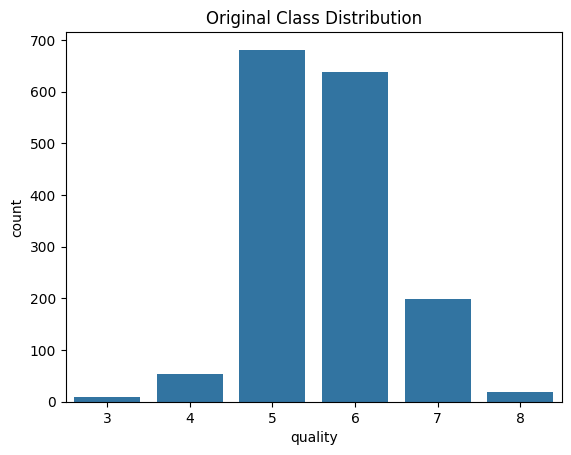

New class distribution after SMOTE:
quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64


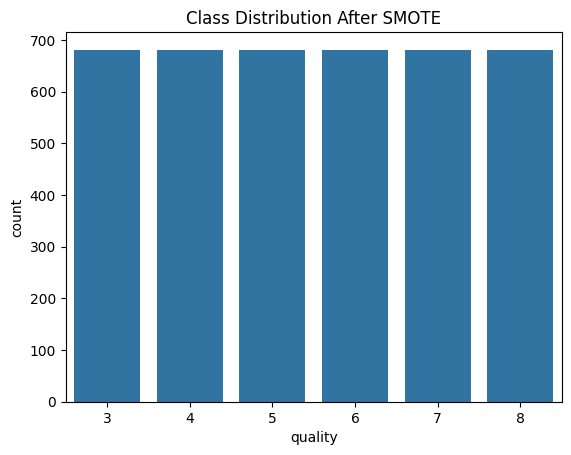

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load the Wine Quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Display original class distribution
print("Original class distribution:")
print(df['quality'].value_counts())

# Visualize original distribution
sns.countplot(x='quality', data=df)
plt.title('Original Class Distribution')
plt.show()

# Separate features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Apply SMOTE to the dataset
smote = SMOTE()
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# smote = SMOTE(sampling_strategy={3: 300, 4: 400, 5: 681, 6: 638, 7: 400, 8:300}, random_state=22)
# smote = SMOTE(sampling_strategy={3: 681, 4: 681, 5: 681, 6: 681, 7: 681, 8: 681}, random_state=22)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine resampled features and target into a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

# Display new class distribution
print("New class distribution after SMOTE:")
print(df_resampled['quality'].value_counts())

# Visualize new distribution
sns.countplot(x='quality', data=df_resampled)
plt.title('Class Distribution After SMOTE')
plt.show()


In [11]:
df.duplicated().sum()

np.int64(240)

In [12]:
df_resampled.duplicated().sum()

np.int64(288)

<b>Comparing the details with the original and new dataframe, surprisingly good</b>>

<b>All in all, this should be now tested with a machine learning model, does it work any better?</b>

In [13]:
df.corr()['quality']

fixed acidity           0.124052
volatile acidity       -0.390558
citric acid             0.226373
residual sugar          0.013732
chlorides              -0.128907
free sulfur dioxide    -0.050656
total sulfur dioxide   -0.185100
density                -0.174919
pH                     -0.057731
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64

In [14]:
df_resampled.corr()['quality']

fixed acidity           0.198794
volatile acidity       -0.689710
citric acid             0.485441
residual sugar         -0.048678
chlorides              -0.326565
free sulfur dioxide     0.090051
total sulfur dioxide    0.046679
density                -0.309106
pH                     -0.343742
sulphates               0.439714
alcohol                 0.615086
quality                 1.000000
Name: quality, dtype: float64

In [15]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [16]:
df_resampled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000
mean,8.355404,0.584923,0.273084,2.631032,0.089897,13.489101,36.863797,0.996549,3.326692,0.659967,10.716457,5.500000
std,1.649276,0.245972,0.204071,1.243406,0.047684,9.771227,28.542481,0.001870,0.153610,0.162137,1.162731,1.708034
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.200000,0.390000,0.070000,1.973603,0.070000,5.975918,15.529549,0.995394,3.217723,0.550000,9.800000,4.000000
50%,8.000000,0.540996,0.270000,2.232477,0.079000,10.584982,27.556761,0.996599,3.320000,0.630000,10.589051,5.500000
75%,9.361167,0.725000,0.441025,2.800000,0.091394,18.000000,48.288309,0.997693,3.425039,0.746928,11.500000,7.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
df.var()

fixed acidity              3.031416
volatile acidity           0.032062
citric acid                0.037947
residual sugar             1.987897
chlorides                  0.002215
free sulfur dioxide      109.414884
total sulfur dioxide    1082.102373
density                    0.000004
pH                         0.023835
sulphates                  0.028733
alcohol                    1.135647
quality                    0.652168
dtype: float64

In [18]:
df_resampled.var()

fixed acidity             2.720111
volatile acidity          0.060502
citric acid               0.041645
residual sugar            1.546058
chlorides                 0.002274
free sulfur dioxide      95.476872
total sulfur dioxide    814.673219
density                   0.000003
pH                        0.023596
sulphates                 0.026288
alcohol                   1.351943
quality                   2.917381
dtype: float64